# Aprendizaje No Supervisado - K-Means

## Segmentación de Clientes mediante Clustering

### Introducción



### En este trabajo práctico se utilizará el modelo K-Means para realizar una segmentación de clientes de una plataforma de comercio electrónico. 
### El objetivo principal será detectar grupos de clientes con comportamientos similares a partir de variables relacionadas con compras y navegación en el sitio web.

### El dataset utilizado contiene información sobre:

### *  Frecuencia de compras mensuales.
### * Ticket promedio por compra.
### * Tiempo de permanencia en el sitio.
### * Sensibilidad a descuentos.
### * Tasa de devoluciones.
  

### A través del análisis se buscará identificar distintos perfiles de clientes y comprender sus características principales para facilitar futuras estrategias de marketing, promociones y fidelización.



## Objetivos del trabajo

### Objetivo general

### Aplicar el modelo K-Means para identificar segmentos latentes de clientes utilizando técnicas de clustering sobre datos sin etiquetas.

### Objetivos específicos

### * Analizar y explorar el dataset.
### * Escalar variables numéricas antes de aplicar K-Means.
### * Utilizar el método del codo para determinar una cantidad adecuada de clusters.
### * Generar agrupamientos utilizando K-Means.
### * Interpretar los centroides obtenidos.
### * Describir perfiles de clientes según sus comportamientos de compra.


## Importo las librerias

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set(style="whitegrid")
colors = ["#C1121F", "#E76F51", "#F4A261", "#E9C46A", "#9D4EDD"]
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

### Cargo el set de datos 

In [38]:
df = pd.read_csv("dataset_segmentacion_clientes.csv")

df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.15,181.30,33.56,1.00,0.80,-1.81,-2.52
1,12.05,178.64,35.43,0.78,0.00,0.65,2.12
2,2.20,450.19,7.03,0.90,0.00,-0.05,-0.72
3,4.23,89.01,10.83,0.00,0.80,0.90,-2.97
4,1.72,449.77,7.25,0.00,0.00,0.39,2.42


# EXPLORACION DEL DATA SET

### Antes de aplicar cualquier modelo de aprendizaje automático es fundamental realizar una exploración inicial de los datos.

### En esta etapa se analizarán:

### * Cantidad de registros y variables.
### * Tipos de datos.
### * Presencia de valores nulos.
### * Estadísticas descriptivas.
### * Distribución de las variables.

### Este análisis permite comprender mejor la estructura del dataset y detectar posibles problemas que puedan afectar el rendimiento del modelo.

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


In [40]:
df.describe()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00
mean,5.88,248.17,16.78,0.43,0.34,0.02,-0.01
std,4.47,154.90,12.91,0.43,0.36,1.01,1.68
min,0.10,86.99,3.16,0.00,0.00,-3.57,-2.99
25%,2.28,90.77,6.60,0.00,0.00,-0.65,-1.42
50%,4.13,180.22,9.97,0.30,0.17,0.08,0.01
75%,11.21,449.72,34.34,1.00,0.80,0.73,1.41
max,14.60,452.97,38.35,1.00,0.80,2.86,3.00


In [41]:
df.isnull().sum()

purchase_freq_month     0
avg_basket_usd          0
time_on_site_min        0
discount_sensitivity    0
returns_rate            0
noise_gauss             0
noise_uniform           0
dtype: int64

## Distribución de variables

### Se observan las distribuciones de las variables para entender sus escalas y comportamientos.

## Histogramas

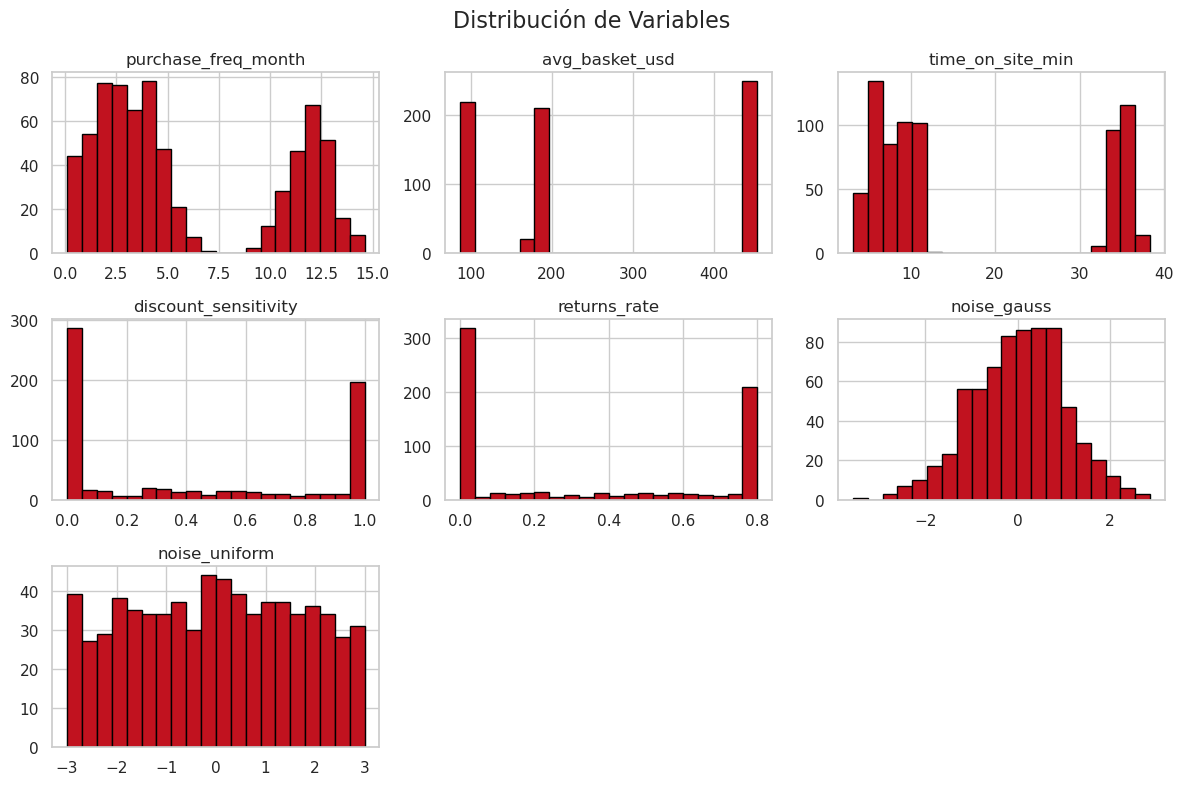

In [42]:
df.hist(
    figsize=(12,8),
    bins=20,
    color="#C1121F",
    edgecolor="black"
)

plt.suptitle("Distribución de Variables", fontsize=16)
plt.tight_layout()
plt.show()

## Escalado de variables

### Las variables del dataset poseen diferentes escalas numéricas. Por ejemplo, el ticket promedio puede expresarse en cientos de dólares mientras que la sensibilidad a descuentos toma valores entre 0 y 1.

### Debido a que K-Means utiliza distancias euclidianas para formar los grupos, las variables con valores más grandes podrían influir excesivamente en el modelo.

### Para evitar este problema se aplicará una estandarización mediante "StandardScaler", transformando las variables para que tengan media 0 y desviación estándar 1.

### De esta manera todas las variables tendrán la misma importancia durante el proceso de clustering.

In [43]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,1.18,-0.43,1.30,1.33,1.30,-1.81,-1.49
1,1.38,-0.45,1.44,0.83,-0.95,0.62,1.27
2,-0.82,1.31,-0.76,1.10,-0.95,-0.07,-0.43
3,-0.37,-1.03,-0.46,-0.99,1.30,0.87,-1.77
4,-0.93,1.30,-0.74,-0.99,-0.94,0.36,1.45


## Método del codo

### Uno de los principales problemas del modelo K-Means consiste en determinar la cantidad adecuada de clusters.

### Para resolver esto se utilizará el método del codo, el cual analiza la evolución de la inercia del modelo para diferentes valores de K.

### La inercia representa la suma de distancias entre las observaciones y sus centroides correspondientes. A medida que aumenta la cantidad de clusters, la inercia disminuye.Sin embargo, llega un punto donde la mejora comienza a ser menor. Ese punto de inflexión es conocido como “codo” y suele indicar una cantidad razonable de clusters para el problema.

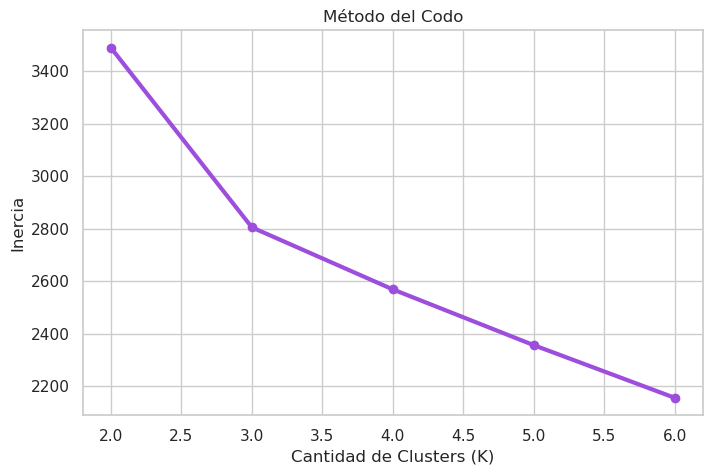

In [44]:
inertia = []

K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia,
    marker='o',
    color="#9D4EDD",
    linewidth=3
)

plt.xlabel("Cantidad de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo")

plt.grid(True)
plt.show()

## Aplicación del modelo K-Means

### Una vez determinado el valor de K mediante el método del codo, se procederá a entrenar el modelo K-Means utilizando las variables escaladas.

### El modelo agrupará automáticamente los clientes según similitudes en sus comportamientos de compra y navegación.

### Posteriormente se agregará la etiqueta de cluster obtenida al dataset original para facilitar el análisis de resultados.

In [45]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_final.fit(scaled_df)

df["cluster"] = kmeans_final.labels_

df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform,cluster
0,11.15,181.30,33.56,1.00,0.80,-1.81,-2.52,0
1,12.05,178.64,35.43,0.78,0.00,0.65,2.12,0
2,2.20,450.19,7.03,0.90,0.00,-0.05,-0.72,2
3,4.23,89.01,10.83,0.00,0.80,0.90,-2.97,1
4,1.72,449.77,7.25,0.00,0.00,0.39,2.42,2


## Análisis de centroides

### Se analizan los centroides obtenidos para identificar las características principales de cada grupo de clientes.

In [46]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.96,180.00,35.02,0.54,0.33,0.05,-0.04
1,4.09,89.96,10.00,0.38,0.30,-0.03,-0.13
2,1.85,450.12,5.97,0.36,0.38,0.05,0.12


In [47]:
df["cluster"].value_counts().reset_index()

,cluster,count
0,2,250
1,0,230
2,1,220


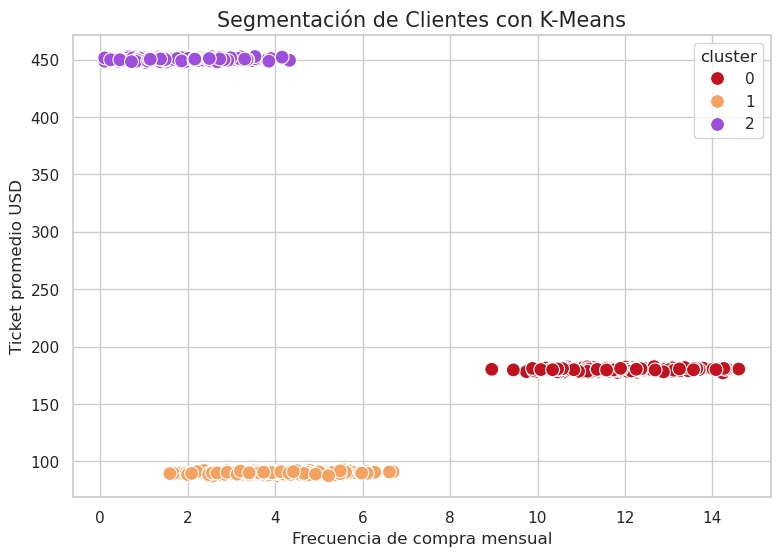

In [48]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="purchase_freq_month",
    y="avg_basket_usd",
    hue="cluster",
    palette=["#C1121F", "#F4A261", "#9D4EDD"],
    s=100
)

plt.title("Segmentación de Clientes con K-Means", fontsize=15)
plt.xlabel("Frecuencia de compra mensual")
plt.ylabel("Ticket promedio USD")

plt.show()

## Análisis

### Luego de generar los agrupamientos se analizarán los centroides obtenidos para comprender las características principales de cada segmento.
### Los centroides representan el comportamiento promedio de los clientes dentro de cada cluster.
### A partir de este análisis será posible identificar perfiles de clientes como:

### * Clientes frecuentes con alta sensibilidad a descuentos.
### * Clientes premium con compras menos frecuentes pero tickets elevados.
### * Clientes exploratorios con mayor tiempo de permanencia y tasas de devolución superiores.
### Esta información resulta de gran utilidad para diseñar estrategias comerciales específicas para cada segmento.

## Boxplot Clusters

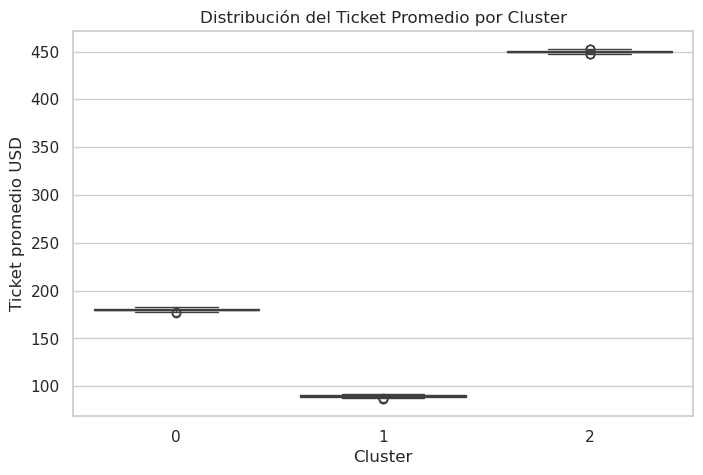

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="cluster",
    y="avg_basket_usd",
    hue="cluster",
    palette=["#C1121F", "#F4A261", "#90D4ED"],
    legend=False
)

plt.title("Distribución del Ticket Promedio por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Ticket promedio USD")

plt.show()

# CONCLUSIONES


### A partir de la aplicación del modelo K-Means fue posible identificar distintos segmentos de clientes utilizando técnicas de aprendizaje no supervisado. Previamente al entrenamiento del modelo se realizó un proceso de escalado de variables utilizando "StandardScaler", debido a que las variables del dataset presentaban diferentes escalas numéricas. Esto permitió evitar que variables como el ticket promedio influyeran excesivamente sobre el algoritmo.

### Posteriormente se aplicó el método del codo comparando valores de K entre 2 y 6 clusters. A partir del gráfico obtenido se observó que la reducción de la inercia comenzaba a estabilizarse en "K = 3", por lo que se seleccionó esa cantidad de clusters para el análisis final.


## Resultados obtenidos

### El modelo permitió identificar tres perfiles principales de clientes:

### Cluster 0
### Características promedio:

### * Frecuencia de compra mensual: aproximadamente 12 compras.
### * Ticket promedio: alrededor de 180 USD.
### * Tiempo en el sitio: 35 minutos.
### * Sensibilidad a descuentos: media/alta.
### * Tasa de devoluciones: media.

### Interpretación:

### Este grupo representa clientes muy activos dentro de la plataforma. Son usuarios que compran frecuentemente y permanecen bastante tiempo navegando en el sitio. Además, presentan cierta sensibilidad a promociones y descuentos, por lo que podrían responder favorablemente a campañas de fidelización y beneficios recurrentes.



### Cluster 1
### Características promedio:

### * Frecuencia de compra mensual: aproximadamente 2 compras.
### * Ticket promedio: 450 USD.
### * Tiempo en el sitio: 6 minutos.
### * Sensibilidad a descuentos: baja/media.
### * Tasa de devoluciones: media.

### Interpretación:

### Este cluster representa clientes premium o de alto valor. Aunque realizan pocas compras, el monto gastado por operación es considerablemente más alto que el resto de los grupos. Además, permanecen menos tiempo en el sitio y muestran menor dependencia de descuentos, lo cual sugiere compras más directas y decididas.



### Cluster 2
### Características promedio:

### * Frecuencia de compra mensual: aproximadamente 4 compras.
### * Ticket promedio: 90 USD.
### * Tiempo en el sitio: 10 minutos.
### * Sensibilidad a descuentos: media.
### * Tasa de devoluciones: relativamente baja.

### Interpretación:

### Este grupo representa clientes de consumo moderado y tickets bajos. Son usuarios que realizan compras más económicas y con menor permanencia en el sitio respecto al Cluster 0. Podrían beneficiarse de estrategias promocionales orientadas a incrementar el valor promedio de compra.



## Conclusión general

### El  modelo permitió detectar patrones de comportamiento diferenciados dentro del conjunto de clientes sin necesidad de contar con etiquetas previas.

### La segmentación obtenida puede resultar útil para:

### * Diseñar campañas de marketing específicas.
### * Personalizar promociones.
### * Detectar clientes premium.
### * Mejorar estrategias de fidelización.
### * Optimizar recomendaciones comerciales.

### En términos generales, el uso de técnicas de clustering representa una herramienta valiosa para descubrir estructuras ocultas en los datos y mejorar la toma de decisiones basada en información objetiva.